📝 This notebook was originally prepared for Nitya Kallivayalil’s Research in Astronomy class and has been adapted for instructional use in the Coding in Astronomy workshop series. Full credit goes to Niusha Ahvazi, Nitya Kallivayalil, and Andrew Pace for the original material and project ideas.

# Gaussian Mixture Models and Identifying Globular Cluster Members


How do astronomers identify which stars belong to a globular cluster versus background "field" stars? This notebook teaches you the statistical tools to solve this problem.

**What You'll Learn:**

We start with simple concepts and build toward advanced techniques:

1. **Gaussian Distributions**: The bell curve and how to describe it
2. **Likelihood**: How to measure whether data supports a hypothesis
3. **Mixture Models**: How to unmix overlapping populations
4. **Bayes' Theorem**: How to combine data with prior knowledge
5. **MCMC Sampling**: How to explore the space of possible solutions

**How to Use This Notebook:**

- Start with simulated data to understand the concepts
- Run each code cell and observe the results
- Try modifying values to build intuition
- Ask yourself: "What does this tell us about the data?"

By the end, you'll understand not just *what* these statistical tools do, but *why* astronomers use them.

## Part 1 — Gaussian Distributions

A Gaussian distribution is defined by:
- Mean (μ): center of the distribution
- Standard deviation (σ): width of the distribution

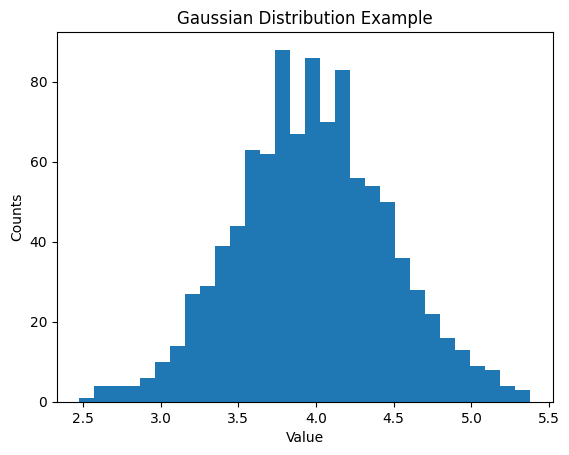

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

mu = 4
sigma = 0.5

data = np.random.normal(mu, sigma, 1000)

plt.hist(data, bins=30)
plt.xlabel("Value")
plt.ylabel("Counts")
plt.title("Gaussian Distribution Example")
plt.show()

### Exercise
Change the values of `mu` and `sigma` and rerun the cell to see how the distribution changes.


## Part 2 — Likelihood Example

### What is Likelihood?

**Likelihood** answers the question: *"Given the data I observe, how probable is this parameter value?"*

In other words:
- You have: A dataset with many measurements
- You want to find: What value of μ (and σ) best explains this data?
- Tool: Likelihood tells you how "good" each guess is

**Mathematical Definition:** For a parameter θ and data D:

Likelihood(θ) = P(D | θ) = probability of observing data D if θ is true

Higher likelihood → better parameter value.

### Why Log-Likelihood?

We actually use **log-likelihood** for practical reasons:
- Probabilities are tiny numbers (e.g., 0.00000001)
- Multiplying tiny numbers causes computer errors
- Taking logs turns multiplication → addition (safer!)
- **Result:** Same ranking, safer math

### The Inverse Problem: Estimating Parameters

In Part 1, we *created* data from a known Gaussian (μ=4, σ=0.5).

Now we flip the problem:
- **Given:** A dataset (you don't know where it came from)
- **Find:** What mean μ does this data suggest?

We'll try many values of μ and calculate the likelihood for each. The μ with the highest likelihood is our best estimate!

### How to Use It

The code below:
1. Defines a function to calculate log-likelihood for any μ value
2. Tests many values of μ (from -2 to +2)
3. Plots likelihood vs. μ to find the peak
4. **You interpret:** Where is the peak? What μ value does it suggest?

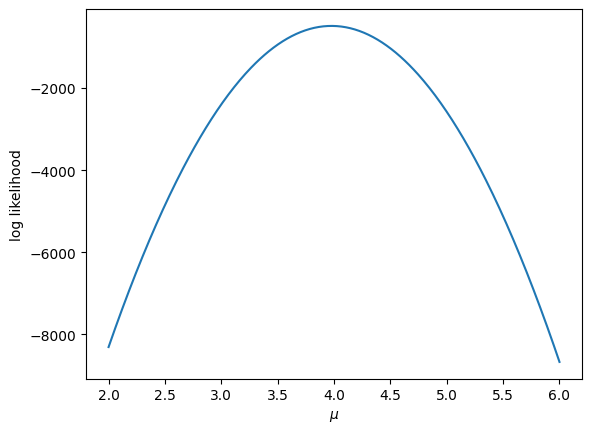

In [ ]:
def log_likelihood(mu,data):
    sigma=0.5
    return -0.5*np.sum((data-mu)**2/sigma**2)

mus=np.linspace(2,6,400)
ll=[log_likelihood(m,data) for m in mus]

plt.plot(mus,ll)
plt.xlabel(r"$\mu$")
plt.ylabel("log likelihood")
plt.show()

Compare your answer with the original mean (4) and the sample mean of the data. **Hint:** They should match!

## Part 3 — Two Populations/Mixture Models


### The Real-World Problem: Mixed Populations

Astronomical datasets often contain **two or more populations mixed together**. In our case:
- **Cluster stars:** All part of the same group, moving together (like a flock of birds)
- **Field stars:** Random background stars, moving randomly (like people walking in different directions on a busy street)

**Key Challenge:** When we look at the data, the two populations overlap! We can't simply draw a line and say "cluster here, field there."

### Proper Motion: Our Measurement Tool

We identify stars using **proper motion**: the apparent movement of a star across the sky over time (measured in milliarcseconds per year, or mas/yr).

**Why it works:**
- Cluster stars move together → similar proper motions
- Field stars move randomly → scattered proper motions
- Different distributions → allows separation!

### Comparing Cluster vs. Field Distributions

| Feature | Cluster Stars | Field Stars |
|---------|--------------|-------------|
| **Typical Motion** | ~4 mas/yr | ~0 mas/yr |
| **Spread (σ)** | Small (0.5) | Large (3) |
| **Pattern** | Tight, organized group | Scattered, random |
| **How Many** | 200 (20% of sample) | 800 (80% of sample) |

### The Challenge: Overlapping Gaussians

When we plot all stars together, we see:
- Two Gaussian distributions, **overlapping**
- Can't tell from the shape alone which star is which
- Need statistics to unmix them (that's what our mixture model does!)

### What This Code Does

The simulation below creates realistic data:
1. Generates 200 cluster stars with tight proper motion distribution
2. Generates 800 field stars with broad proper motion distribution
3. Mixes them together (like real observations)
4. Plots all three: individual populations AND the combined population


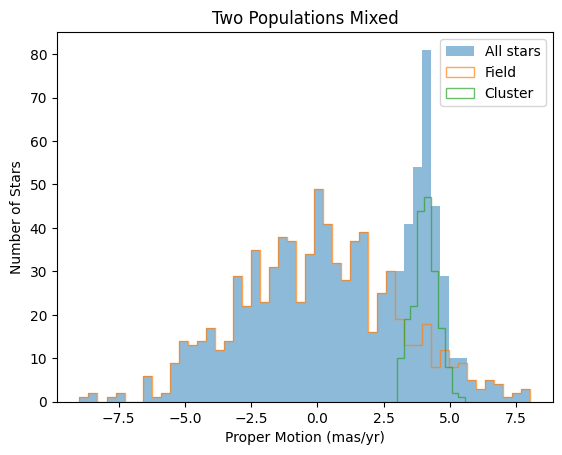

In [ ]:
cluster_pm = np.random.normal(4, 0.5, 200)  # cluster: mean 4 mas/yr, tight
field_pm = np.random.normal(0, 3, 800)     # field: mean 0, broad

all_pm = np.concatenate([cluster_pm,field_pm])

plt.hist(all_pm,bins=50, alpha=0.5, label='All stars')
plt.hist(field_pm, bins=50, lw = 2, histtype = 'step', alpha=0.7, label='Field')
plt.hist(cluster_pm, bins=10, lw = 2, histtype = 'step', alpha=0.7, label='Cluster')
plt.xlabel("Proper Motion (mas/yr)")
plt.ylabel("Number of Stars")
plt.legend()
plt.title("Two Populations Mixed")
plt.show()

**Your task:** Look at the combined histogram. Can you visually spot the cluster peak? Change the cluster sample size from 20% to 10%, can you still spot the cluster peak? It's harder than you think!


## Part 4 — Likelihood for Mixture Model


### The Challenge: One Star, Two Possible Origins

For a single star with measured proper motion, we face a question:
- "Is this star more likely from the **cluster** or the **field**?"

In a mixture model, we DON'T assume we know the answer. Instead, we:
1. Calculate probability it came from cluster
2. Calculate probability it came from field
3. **Combine both** weighted by the fraction f

### The Mixture Likelihood Formula

For a single star i with data value data_i:

**P(data_i | model) = f × P_cluster(data_i) + (1-f) × P_field(data_i)**

**Breaking it down:**

| Term | Meaning |
|------|---------|
| **f** | Fraction of stars that are cluster members (0 to 1) |
| **P_cluster(data_i)** | Probability star i has that proper motion IF it's from cluster |
| **(1-f)** | Fraction of stars from field (1 - f) |
| **P_field(data_i)** | Probability star i has that proper motion IF it's from field |

**Intuition:** We're saying "this star MIGHT be cluster (with weight f) or field (with weight 1-f)." We average both possibilities.

### Full Log-Likelihood: All Stars Together

For ALL N stars in our dataset:

**log L = Σ log [ f × P_cluster(i) + (1-f) × P_field(i) ]**

(sum over all i = 1 to N)

**Why add logs?** Because:
- Probabilities multiply: P_total = P_1 × P_2 × P_3 × ...
- But logs add: log P_total = log P_1 + log P_2 + log P_3 + ...
- Safer for computers (avoids underflow errors)

### Comparing to Single Models

| Model Type | Formula | Parameters |
|-----------|---------|------------|
| **Single Population (Part 2)** | log [P(data \| μ, σ)] | Just 2: μ, σ |
| **Mixture Model (Part 4)** | log [ f × P_cluster + (1-f) × P_field ] | 5: μ_c, σ_c, μ_f, σ_f, f |

The mixture version is more flexible but harder to optimize.

### How We Use Likelihood to Find Best Parameters

**Same strategy as Part 2, but now 5 parameters:**
1. Guess starting values for (μ_c, σ_c, μ_f, σ_f, f)
2. For each guess, calculate log-likelihood
3. **Find the guess with highest log-likelihood** (best fit)
4. That's our best estimate!

**Grid search** tries many values.  
**MCMC** (next section) does this smarter.

### What This Code Does

The code below:
1. Defines `log_likelihood_mixture()`, calculates score for ANY parameters
2. Tests the "true" parameters (μ_c=4, σ_c=0.5, etc.)
3. Does a grid search: tries many μ_c values, keeps others fixed (for simplicity)
4. Plots likelihood vs. μ_c to find the peak
5. **You interpret:** Where is the peak? Is it at μ_c ≈ 4 (the true value)?

Log likelihood for true params: -2456.865647094368


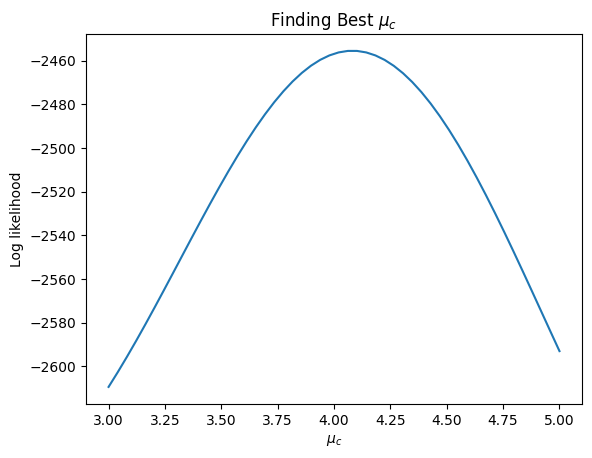

In [ ]:
def log_likelihood_mixture(theta, data):
    mu_c, sig_c, mu_f, sig_f, f = theta
    cluster = f * (1/np.sqrt(2*np.pi*sig_c**2)) * np.exp(-(data - mu_c)**2 / (2*sig_c**2))
    field = (1-f) * (1/np.sqrt(2*np.pi*sig_f**2)) * np.exp(-(data - mu_f)**2 / (2*sig_f**2))
    total = cluster + field
    return np.sum(np.log(total))

# Test on our simulated data
theta_true = [4, 0.5, 0, 3, 0.2]  # approx true params
ll = log_likelihood_mixture(theta_true, all_pm)
print(f"Log likelihood for true params: {ll}")

# Grid search for best mu_c
mu_cs = np.linspace(3,5,50)
#frac=np.linspace(0.1, 0.5, 100)

lls = [log_likelihood_mixture([mu, 0.5, 0, 3, 0.2], all_pm) for mu in mu_cs]
#lls = [log_likelihood_mixture([4.0, 0.5, 0, 3, f], all_pm) for f in frac]

plt.plot(mu_cs, lls)
plt.xlabel(r"$\mu_{c}$")
#plt.xlabel("$f$")
plt.ylabel("Log likelihood")

plt.title(r"Finding Best $\mu_{c}$")
#plt.title(r"Finding Best $f$")
plt.show()

## Part 5 — Bayes’ Theorem  

### What Bayes’ Theorem Says

Bayes’ theorem tells us how to update our belief about a hypothesis when we see data.

\begin{align}
P(\theta \mid D) = \frac{P(D \mid \theta)\,P(\theta)}{P(D)}
\end{align}

where:

- **$P(\theta \mid D)$** is the **posterior**: our updated probability for the parameter set $\theta$ after seeing the data D.
- **$P(D \mid \theta)$** is the **likelihood**: the same quantity we’ve been computing in the previous section.
- **$P(\theta)$** is the **prior**: what we believed about $\theta$ *before* looking at the data.
- **$P(D)$** is a normalizing constant (often ignored when exploring the posterior).

For a great visual explanation of Bayes' theorem, watch this video:

[![Bayes' Theorem](https://img.youtube.com/vi/HZGCoVF3YvM/0.jpg)](https://www.youtube.com/watch?v=HZGCoVF3YvM)

### Connecting to Mixture Model

In a mixture‑model context, $\theta$ represents the five parameters of the cluster+field model: means, dispersions, and the fraction $f$.  
- The likelihood $P(D\mid\theta)$ evaluates how well those parameters explain every star’s proper motion.
- The prior $P(\theta)$ encodes sensible ranges (e.g. dispersion must be positive, $0\le f\le1$).

**Why bother with priors?**  
They prevent the sampler from exploring unphysical regions and allow us to include any external information (for example, we might know the cluster’s proper motion roughly from other studies).

Interested to explore more? Check out [this notebook](https://colab.research.google.com/github/Niusha951/Astronomy_Python_Course/blob/master/Week3_Data_Analysis/Bayesian_Inference.ipynb) for simple examples of how changing your priors can affect your posterior.


## Part 6 — MCMC for Mixture Parameters

### Why Not Just Maximize the Likelihood?

We could try to find the parameter set that gives the highest likelihood (a single “best fit”), but:

* The likelihood surface is **high‑dimensional** (5+ parameters) and may have
  ridges, valleys, or multiple peaks.
* We also have **priors** to include (e.g. $(0<f<1)$, dispersions >0).
* We want uncertainties and correlations, not just a point estimate.

### Enter MCMC

**Markov Chain Monte Carlo (MCMC)** is a family of algorithms that draw
samples from the *posterior* distribution


$P(\theta \mid D) \propto P(D \mid \theta) P(\theta)$


by performing a random walk in parameter space. Each step proposes a new
θ; the walk is biased toward regions of high posterior probability. **Emcee** is a Python tool for this.

**In plain language:**

1. Start with an initial guess for the five parameters
   ($\mu_c,\sigma_c,\mu_f,\sigma_f,f$).
2. Propose a small random change.
3. Compute the **posterior probability** of the new point (likelihood ×
   prior).
4. Accept the new point if it has higher posterior; otherwise accept it
   with a probability proportional to how much worse it is.
5. Repeat thousands of times. The chain of accepted points samples the
   posterior.

Over many steps the sampler collects a “cloud” of points. Regions with
more points are more probable.

### Important Concepts

* **Burn‑in:** The early steps depend on the starting guess. We discard
  them before analysing the samples.
* **Walkers:** emcee uses many parallel chains (“walkers”) to explore
  parameter space more efficiently.
* **Priors:** These encode our basic physical constraints (e.g. $0<\sigma$,
  $0<f<1$). They prevent the sampler from wandering into nonsense regions.
* **Posterior:** What we ultimately want. It tells us not only the most
  likely parameters but also their uncertainties and mutual correlations.
* **Corner plot:** A visualization of the posterior samples showing
  marginal distributions and covariances.

### What the Code Below Does

* Defines `log_prior` and `log_prob` (posterior) using the likelihood
  from Part 4.
* Sets up 20 walkers in a 5‑dimensional parameter space.
* Runs 2000 steps of emcee’s ensemble sampler, printing progress.
* Discards the first 500 steps (“burn‑in”) and flattens the chains.
* Plots the posterior samples with `corner` and prints the median values.

### Why This Matters

Once we have posterior samples we can:

* Quote credible intervals (e.g. “$\mu_c=4.1\pm0.2$ mas/yr”).
* See if parameters are correlated (e.g. larger σ_c might allow a
  different μ_c).
* Compute membership probabilities for stars using the full
  distribution of parameters.



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.4 MB/s eta 0:00:00


100%|██████████| 2000/2000 [00:05<00:00, 359.57it/s]


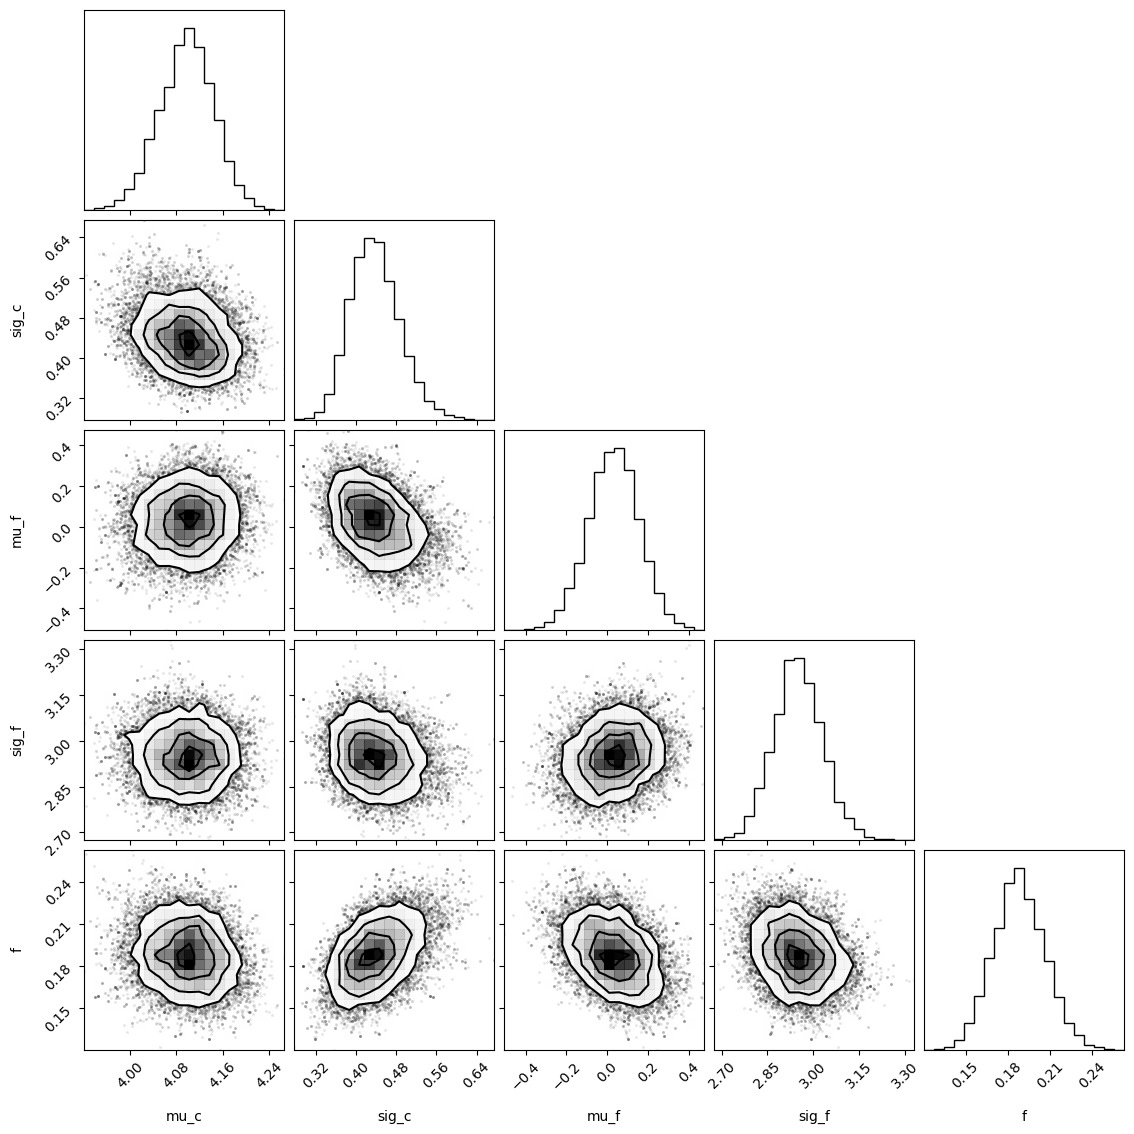

Median params: [4.0991685  0.43590447 0.03223154 2.94945677 0.18782163]


In [ ]:
! pip install emcee corner

import emcee
import corner

def log_prior(theta):
    mu_c, sig_c, mu_f, sig_f, f = theta
    if 0 < sig_c < 2 and 0 < sig_f < 10 and 0 < f < 1:
        return 0
    return -np.inf

def log_prob(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_mixture(theta, all_pm)

nwalkers = 20
ndim = 5
initial = np.array([4, 0.5, 0, 3, 0.2]) + 0.1 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
sampler.run_mcmc(initial, 2000, progress=True)

flat_samples = sampler.get_chain(flat=True, discard=500)


fig = corner.corner(flat_samples, labels=["mu_c", "sig_c", "mu_f", "sig_f", "f"])
plt.show()

print("Median params:", np.median(flat_samples, axis=0))